# SL-6 --- Moteurs ILP modernes : Aleph, Metagol, Popper et dILP

**Navigation** : [Index](./README.md) | [<< SL-5 Resolution inverse](SL-5-InverseResolution.ipynb) | [SL-7 Neuro-symbolique >>](SL-7-NeuroSymbolic.ipynb)

## Objectifs d'apprentissage

Les notebooks SL-4 (top-down, FOIL) et SL-5 (bottom-up, resolution inverse / Progol)
ont construit les fondations de l'ILP **a la main**. Ce notebook met en scene quatre
**moteurs ILP reels** -- les bibliotheques que chercheurs et praticiens utilisent
reellement -- sur **une seule et meme tache** : apprendre la relation recursive
`ancestor/2` (la cloture transitive de `parent/2`).

A la fin de ce notebook, vous saurez :
1. Lancer **quatre vrais moteurs ILP** (et non des reimplementations jouet) sur une tache commune
2. Distinguer leurs **paradigmes** : entailment inverse (Aleph), meta-interpretation (Metagol),
   apprentissage par l'echec (Popper), descente de gradient (dILP)
3. Reconnaitre l'**invention de predicat** (Metagol) et la **sensibilite au biais de langage** (Aleph)
4. Comprendre pourquoi un moteur **differentiable** (dILP) fait le pont vers le neuro-symbolique (SL-7)
5. Choisir le moteur adapte selon la tache (exactitude symbolique vs robustesse au bruit)

> **Note d'execution.** Ce notebook utilise le kernel **Python 3 (WSL)**. Chaque moteur
> tourne dans un **sous-processus isole** : l'etat global de Prolog/janus/Popper se
> cumulerait sinon d'un apprentissage a l'autre (faits consultes, exemples comptes deux fois).
> Les trois moteurs symboliques (Aleph, Metagol, Popper) sont natifs du kernel WSL ;
> le moteur differentiable (dILP / Lernd) est appele via un sous-processus vers un
> environnement TensorFlow dedie (voir la section dILP pour son installation).

## Quatre paradigmes, une seule tache

Tous les moteurs recoivent **exactement le meme probleme** : a partir de la relation
`parent/2` d'une famille, apprendre la relation **recursive** `ancestor/2`. Ils y
parviennent tous -- mais par des **machineries fondamentalement differentes**.

| Moteur | Paradigme | Reference | Recherche | Invention de predicat | Differentiable |
|--------|-----------|-----------|-----------|:--------------------:|:--------------:|
| **Aleph** | Entailment inverse (Progol) | Srinivasan 2001 | bottom-up, clause bottom | non (ici) | non |
| **Metagol** | Meta-Interpretive Learning | Muggleton et al. 2015 | metaregles + abduction | **oui** (natif) | non |
| **Popper** | Learning From Failures | Cropper & Morel 2021 | generate-test-constrain (ASP) | oui (via biais) | non |
| **dILP** | ILP differentiable | Evans & Grefenstette 2018 | descente de gradient | non (templates) | **oui** |

Les **discriminateurs reels** que ce notebook met en lumiere :

- **Invention de predicat** : Metagol invente spontanement un predicat auxiliaire
  (`ancestor_1`, qui se trouve etre `grandparent`) ; les trois autres apprennent
  `ancestor` directement ici.
- **Biais de langage** : Aleph exige des **declarations de modes** explicites et y est
  sensible -- la *direction* d'un mode (`+` entree vs `-` sortie) peut casser
  l'apprentissage, on le montre en exercice ; Popper se contente d'un `enable_recursion` ;
  dILP encode le biais dans des **templates de regles**.
- **Differentiabilite** : dILP apprend par **descente de gradient** (on trace la courbe
  de perte), s'etend aux **donnees bruitees**, et fait le pont vers les approches
  neuronales du notebook SL-7.

In [1]:
# Base de connaissances commune -- source UNIQUE de verite pour les 4 moteurs.
# On NE liste PAS les ancetres a la main : on calcule la cloture transitive en code.
# (Une liste manuelle oubliait ancestor(bob, sue) via bob -> ann -> sue : 10 au lieu de 11.)

PEOPLE = ["tom", "bob", "ann", "pat", "jim", "sue"]
PARENT = [("tom", "bob"), ("bob", "ann"), ("bob", "pat"), ("pat", "jim"), ("ann", "sue")]


def transitive_closure(edges):
    """Cloture transitive de `edges` : les vrais couples ancestor(X, Y)."""
    succ = {}
    for a, b in edges:
        succ.setdefault(a, set()).add(b)
    cur = set(edges)
    while True:
        nxt = set(cur)
        for a, b in cur:
            for c in succ.get(b, ()):
                nxt.add((a, c))
        if nxt == cur:
            return cur
        cur = nxt


POS = sorted(transitive_closure(PARENT))
NEG = sorted((x, y) for x in PEOPLE for y in PEOPLE if x != y and (x, y) not in set(POS))

print(f"parent/2 : {len(PARENT)} faits -> {PARENT}")
print(f"positifs : {len(POS)} couples ancestor (cloture transitive)")
for a, b in POS:
    print(f"    ancestor({a}, {b})")
print(f"negatifs : {len(NEG)} couples (x != y, hors cloture)")

parent/2 : 5 faits -> [('tom', 'bob'), ('bob', 'ann'), ('bob', 'pat'), ('pat', 'jim'), ('ann', 'sue')]
positifs : 11 couples ancestor (cloture transitive)
    ancestor(ann, sue)
    ancestor(bob, ann)
    ancestor(bob, jim)
    ancestor(bob, pat)
    ancestor(bob, sue)
    ancestor(pat, jim)
    ancestor(tom, ann)
    ancestor(tom, bob)
    ancestor(tom, jim)
    ancestor(tom, pat)
    ancestor(tom, sue)
negatifs : 19 couples (x != y, hors cloture)


## 1. Aleph -- entailment inverse (la lignee Progol)

**Aleph** (*A Learning Engine for Proposing Hypotheses*, Srinivasan 2001) est
l'implementation de reference de l'**entailment inverse** introduit par Progol (SL-5).
Pour chaque exemple positif, il construit la **clause bottom** -- la clause la plus
specifique qui couvre cet exemple compte tenu du biais -- puis cherche par
generalisation une clause courte qui couvre un maximum de positifs et aucun negatif.

Son biais de langage est declare par des **modes** :
`modeh` (tete autorisee), `modeb` (litteraux de corps autorises), avec la *direction*
des arguments (`+person` = variable d'entree deja liee, `-person` = variable de sortie),
et `determination/2` qui liste les predicats admis dans le corps. Pour apprendre une
relation **recursive**, on declare explicitement la recursion :
`modeb(ancestor(+person, -person))` + `determination(ancestor/2, ancestor/2)`.

In [2]:
# Environnement Aleph : SWI-Prolog (swipl) + pont janus_swi + pack `aleph`.
import shutil
import janus_swi as janus

HAS_ALEPH = False
swipl = shutil.which("swipl")
print(f"swipl : {swipl or 'INTROUVABLE'}")
if swipl is not None:
    if not janus.query_once("pack_property(aleph, version(_V))")["truth"]:
        print("Installation du pack aleph (une seule fois)...")
        janus.query_once("pack_install(aleph, [interactive(false)])")
    v = janus.query_once("pack_property(aleph, version(V))")
    HAS_ALEPH = bool(v["truth"])
    print(f"pack aleph : version {v['V']}" if HAS_ALEPH else "pack aleph : INTROUVABLE")
else:
    print("SWI-Prolog manquant : sudo apt install swi-prolog (kernel python3-wsl).")

swipl : /usr/bin/swipl
pack aleph : version 5


In [3]:
# Aleph tourne dans un sous-processus isole (janus garde un etat Prolog global par
# processus). On ecrit la tache au format Aleph (modes, determinations, bg, exemples),
# on lance `induce`, et on recupere la theorie apprise.
import json
import subprocess
import sys
import tempfile
from pathlib import Path

ALEPH_RUNNER = r"""
import sys, re
import janus_swi as janus
janus.query_once("consult('" + sys.argv[1] + "')")
# Le pack SWI `aleph` n'expose pas la theorie via induce(-P) : induce/0 la *trace*
# (bloc [theory]) puis l'evalue. On capture la trace et on en extrait les clauses.
r = janus.query_once("with_output_to(string(S), induce)")
S = (r or {}).get("S", "") if r else ""
prog = ""
m = re.search(r"\[theory\](.*?)\[Training set performance\]", S, re.S)
if m:
    clauses = []
    for chunk in re.split(r"\n\s*\n", m.group(1)):
        body = "\n".join(l for l in chunk.splitlines()
                         if not l.strip().startswith("[Rule")).strip()
        if body:
            clauses.append(re.sub(r"\s+", " ", body))
    prog = "\n".join(clauses)
ma = re.search(r"Accuracy = ([\d.]+)", S)
print("===ALEPH_PROG===")
print(prog)
print("===ALEPH_ACC===")
print(ma.group(1) if ma else "")
"""


def _fact(s):
    return s + "."


def run_aleph(pos, neg):
    bg = [_fact(f"person({p})") for p in PEOPLE] + [_fact(f"parent({a},{b})") for a, b in PARENT]
    task = "\n".join([
        ":- use_module(library(aleph)).",
        ":- aleph.",
        ":- style_check(-discontiguous).",
        ":- aleph_set(verbosity, 1).",
        ":- aleph_set(clauselength, 4).",
        ":- aleph_set(depth, 6).",
        ":- modeh(*, ancestor(+person, -person)).",
        ":- modeb(*, parent(+person, -person)).",
        ":- modeb(*, ancestor(+person, -person)).",
        ":- determination(ancestor/2, parent/2).",
        ":- determination(ancestor/2, ancestor/2).",
        ":- begin_bg.", *bg, ":- end_bg.",
        ":- begin_in_pos.", *[_fact(f"ancestor({a},{b})") for a, b in pos], ":- end_in_pos.",
        ":- begin_in_neg.", *[_fact(f"ancestor({a},{b})") for a, b in neg], ":- end_in_neg.",
    ])
    f = Path(tempfile.mkdtemp(prefix="aleph_anc_")) / "anc.pl"
    f.write_text(task)
    out = subprocess.run([sys.executable, "-c", ALEPH_RUNNER, str(f)],
                         capture_output=True, text=True, timeout=300)
    _, _, rest = out.stdout.partition("===ALEPH_PROG===")
    prog, _, acc = rest.partition("===ALEPH_ACC===")
    return prog.strip(), acc.strip()


if HAS_ALEPH:
    aleph_prog, aleph_acc = run_aleph(POS, NEG)
    print("Programme appris par Aleph :\n")
    print(aleph_prog)
    if aleph_acc:
        print(f"\nExactitude sur l'ensemble d'apprentissage : Accuracy = {aleph_acc}")
else:
    aleph_prog = None
    print("Aleph indisponible : cellule sautee.")

Programme appris par Aleph :

ancestor(A,B) :- parent(A,B).
ancestor(A,B) :- parent(A,C), ancestor(C,B).

Exactitude sur l'ensemble d'apprentissage : Accuracy = 1


Aleph apprend le programme **optimal** en deux clauses -- le cas de base et le pas
recursif -- avec une exactitude de 100 % (11 positifs, 19 negatifs) :

```prolog
ancestor(A, B) :- parent(A, B).
ancestor(A, B) :- parent(A, C), ancestor(C, B).
```

> **Aparte : la direction des modes est un vrai piege.** Le succes ci-dessus depend de
> `modeh(ancestor(+person, -person))`. Avec `+person, +person` (deux entrees), la tete
> n'a **aucune variable de sortie** : la saturation est impossible et `induce` echoue.
> Ce n'est *pas* qu'Aleph ignore la recursion -- c'est la sensibilite au biais de langage.
> L'exercice 1 vous fait reproduire les deux cas cote a cote.

## 2. Metagol -- Meta-Interpretive Learning (MIL)

**Metagol** (Muggleton, Lin, Tamaddoni-Nezhad 2015) apprend en **abduisant** des
substitutions sur des **metaregles** -- des squelettes de clauses d'ordre superieur.
Sa signature : il **invente des predicats auxiliaires** quand la cible ne tient pas dans
les metaregles fournies. Ici, avec une metaregle *base* (`P(A,B) :- Q(A,B)`) et une
metaregle *chain* (`P(A,B) :- Q(A,C), R(C,B)`), Metagol invente de lui-meme un predicat
`ancestor_1` (qui se revele etre `grandparent`) pour structurer la recursion.

Le moteur (`metagol.pl`, licence BSD-3) est **embarque dans le depot**
(`vendor/metagol/`, avec sa licence et son attribution) : le projet upstream est
archive, ses auteurs renvoient desormais vers Popper.

In [4]:
# Environnement Metagol : swipl + le fichier vendore metagol.pl.
import os
import shutil

HAS_METAGOL = False
swipl = shutil.which("swipl")
_cands = [
    os.environ.get("METAGOL_PL", ""),
    "/mnt/d/CoursIA/MyIA.AI.Notebooks/SymbolicAI/SymbolicLearning/vendor/metagol/metagol.pl",
    os.path.join(os.getcwd(), "vendor", "metagol", "metagol.pl"),
    os.path.join(os.path.dirname(os.getcwd()), "SymbolicLearning", "vendor", "metagol", "metagol.pl"),
]
METAGOL_PL = next((c for c in _cands if c and os.path.exists(c)), None)
print(f"swipl       : {swipl or 'INTROUVABLE'}")
print(f"metagol.pl  : {METAGOL_PL or 'INTROUVABLE'}")
HAS_METAGOL = bool(swipl and METAGOL_PL)
if not HAS_METAGOL:
    print("Metagol indisponible : verifier swipl + le chemin vendor/metagol/metagol.pl "
          "(variable d'env METAGOL_PL pour forcer le chemin).")

swipl       : /usr/bin/swipl
metagol.pl  : /mnt/d/CoursIA/MyIA.AI.Notebooks/SymbolicAI/SymbolicLearning/vendor/metagol/metagol.pl


In [5]:
# Metagol via swipl en sous-processus : on copie metagol.pl dans un repertoire de
# tache, on y ajoute metaregles + body_pred + faits + l'appel a learn/3.
import shutil as _sh
import subprocess
import tempfile
from pathlib import Path

if HAS_METAGOL:
    task = Path(tempfile.mkdtemp(prefix="metagol_anc_"))
    _sh.copy(METAGOL_PL, task / "metagol.pl")
    facts = "\n".join(f"parent({a},{b})." for a, b in PARENT)
    pos = "[" + ",".join(f"ancestor({a},{b})" for a, b in POS) + "]"
    neg = "[" + ",".join(f"ancestor({a},{b})" for a, b in NEG) + "]"
    prog = "\n".join([
        ":- use_module('" + (task / "metagol").as_posix() + "').",
        ":- use_module(library(lists)).",
        ":- style_check(-singleton).",
        "metagol:max_clauses(5).",
        "body_pred(parent/2).",
        "metarule([P,Q],[P,A,B],[[Q,A,B]]).            % base : P(A,B) :- Q(A,B)",
        "metarule([P,Q,R],[P,A,B],[[Q,A,C],[R,C,B]]).  % chain : P(A,B) :- Q(A,C), R(C,B)",
        facts,
        f":- ( Pos={pos}, Neg={neg}, learn(Pos,Neg,Prog) -> "
        f"nl, write('===METAGOL_PROG==='), nl, pprint(Prog) ; "
        f"write('metagol_learn_failed'), nl ), halt.",
    ])
    (task / "anc.pl").write_text(prog)
    out = subprocess.run([swipl, "-q", "-g", "true", str(task / "anc.pl")],
                         capture_output=True, text=True, timeout=300)
    _, _, learned = out.stdout.partition("===METAGOL_PROG===")
    metagol_prog = learned.strip()
    print("Programme appris par Metagol :\n")
    print(metagol_prog)
else:
    metagol_prog = None
    print("Metagol indisponible : cellule sautee.")

Programme appris par Metagol :

ancestor(A,B):-parent(A,B).
ancestor(A,B):-ancestor_1(A,B).
ancestor_1(A,B):-parent(A,C),parent(C,B).
ancestor(A,B):-parent(A,C),ancestor_1(C,B).


Metagol apprend `ancestor` **avec invention de predicat** -- remarquez `ancestor_1`,
qui n'etait dans aucune donnee d'entree :

```prolog
ancestor(A, B) :- parent(A, B).
ancestor(A, B) :- ancestor_1(A, B).
ancestor_1(A, B) :- parent(A, C), parent(C, B).   % <- predicat invente (= grandparent)
ancestor(A, B) :- parent(A, C), ancestor_1(C, B).
```

C'est la difference qualitative avec Aleph et Popper : la **meta-interpretation** permet
d'introduire des symboles **hors du vocabulaire fourni**, et donc d'apprendre des
theories structurees en sous-concepts reutilisables.

## 3. Popper -- Learning From Failures (LFF)

**Popper** (Cropper & Morel 2021) reformule l'ILP comme une boucle
**generate / test / constrain** : il genere une hypothese candidate (via le solveur
ASP *clingo*), la teste contre les exemples (en Prolog), et quand elle echoue il en
deduit des **contraintes** qui elaguent tout un pan de l'espace d'hypotheses. C'est le
moteur ILP general le plus actif aujourd'hui -- celui que les auteurs de Metagol
recommandent desormais. Il gere recursion et invention de predicat via un **biais
declaratif** compact.

In [6]:
# Environnement Popper : kernel Python Linux requis (SIGALRM absent de Windows) + clingo.
import importlib.util
import platform
import shutil
import subprocess
import sys
import warnings

HAS_POPPER = False
swipl = shutil.which("swipl")
print(f"Python : {sys.version.split()[0]} ({platform.system()})")
print(f"swipl  : {swipl or 'INTROUVABLE'}")
if platform.system() != "Linux":
    print("\nPopper requiert un OS Unix (SIGALRM) : utiliser le kernel 'python3-wsl'.")
elif swipl is None:
    print("\nSWI-Prolog manquant : sudo apt install swi-prolog.")
else:
    if importlib.util.find_spec("popper") is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                               "setuptools<81", "clingo",
                               "git+https://github.com/logic-and-learning-lab/Popper@v4.4.0"])
    warnings.filterwarnings("ignore", message=".*pkg_resources.*")
    import clingo
    import popper  # noqa: F401
    HAS_POPPER = True
    print(f"clingo : {clingo.__version__}")
    print("Popper : v4.4.0 -- pret")

Python : 3.12.3 (Linux)
swipl  : /usr/bin/swipl
clingo : 5.8.0
Popper : v4.4.0 -- pret


In [7]:
# Popper en sous-processus isole : son testeur Prolog garde un etat global par
# processus. Un patch de compatibilite v4.4.0 ordonne le litteral recursif en dernier.
import json
import subprocess
import sys
import tempfile
from pathlib import Path

POPPER_RUNNER = r"""
import json, sys, warnings
warnings.filterwarnings("ignore")
from popper.util import Settings, format_prog
def tmp_score_(self, seen_vars, literal):
    pred, args = literal
    return self.recall.get((pred, tuple(1 if x in seen_vars else 0 for x in args)), float("inf"))
Settings.tmp_score_ = tmp_score_
from popper.loop import learn_solution
settings = Settings(kbpath=sys.argv[1], quiet=True)
prog, score, stats = learn_solution(settings)
print(json.dumps({"prog": format_prog(prog) if prog else None, "score": score}))
"""


def run_popper(kbpath):
    out = subprocess.run([sys.executable, "-c", POPPER_RUNNER, str(kbpath)],
                         capture_output=True, text=True, timeout=300)
    return json.loads(out.stdout.strip().splitlines()[-1])


if HAS_POPPER:
    task = Path(tempfile.mkdtemp(prefix="popper_ancestor_"))
    (task / "bk.pl").write_text("".join(f"parent({a},{b}).\n" for a, b in PARENT))
    (task / "exs.pl").write_text(
        "".join(f"pos(ancestor({a},{b})).\n" for a, b in POS) +
        "".join(f"neg(ancestor({a},{b})).\n" for a, b in NEG))
    (task / "bias.pl").write_text(
        "max_vars(3).\nmax_body(2).\nmax_clauses(2).\n"
        "head_pred(ancestor,2).\nbody_pred(parent,2).\nenable_recursion.\n")
    popper_res = run_popper(task)
    tp, fn, tn, fp, size = popper_res["score"]
    popper_prog = popper_res["prog"]
    print("Programme appris par Popper :\n")
    print(popper_prog)
    print(f"\nScore : {tp} tp, {fn} fn, {tn} tn, {fp} fp -- taille {size} litteraux")
else:
    popper_prog = None
    print("Popper indisponible : cellule sautee.")

Programme appris par Popper :

ancestor(V0,V1):- ancestor(V2,V1),parent(V0,V2).
ancestor(V0,V1):- parent(V0,V1).

Score : 11 tp, 0 fn, 19 tn, 0 fp -- taille 5 litteraux


Popper apprend le programme recursif **optimal**, avec un score parfait
(11 vrais positifs, 0 faux negatif, 19 vrais negatifs, 0 faux positif) :

```prolog
ancestor(A, B) :- parent(A, B).
ancestor(A, B) :- parent(A, C), ancestor(C, B).
```

La force de LFF est de **transformer chaque echec en contrainte** : plutot que d'enumerer
les hypotheses, Popper exclut des sous-espaces entiers. Cela le rend efficace sur des
problemes ou l'espace d'hypotheses est trop grand pour une recherche bottom-up.

## 4. dILP -- ILP differentiable (Lernd)

**dILP** (Evans & Grefenstette, *Learning Explanatory Rules from Noisy Data*,
JAIR 2018) remplace la recherche discrete par une **optimisation continue** : chaque
regle candidate recoit un **poids**, l'inference logique est rendue differentiable, et
on apprend les poids par **descente de gradient** (perte d'entropie croisee sur les
exemples). Avantages : robustesse au **bruit** et passerelle directe vers le
neuro-symbolique (SL-7). Limite : il faut borner l'espace via des **templates de regles**.

> **Implementation reelle.** DeepMind n'a jamais publie de code officiel pour dILP.
> On utilise ici **Lernd** (`github.com/crunchiness/lernd`), une implementation fidele
> de l'algorithme, sous licence **GPL-3.0**. Conformement a la GPL, on se contente de
> l'**importer** depuis un environnement dedie (jamais de copie de son source dans ce
> depot MIT). L'environnement TensorFlow est separe du kernel et appele par sous-processus.

Installation de l'environnement dILP (une fois, hors notebook) :

```bash
conda create -n lernd-dilp python=3.8 -y
conda activate lernd-dilp
pip install "tensorflow==2.7.2" "protobuf==3.19.6" "ordered-set==4.0.2" matplotlib
git clone https://github.com/crunchiness/lernd  C:/Users/<vous>/lernd-src
```

Le notebook localise l'environnement via les variables `LERND_PYTHON` (l'interpreteur
de l'env) et `LERND_SRC` (le clone de Lernd) ; si l'env
est absent, la section se saute proprement (`HAS_LERND = False`).

In [8]:
# Environnement dILP/Lernd : interpreteur Windows dedie appele depuis le kernel WSL.
import os
import subprocess

LERND_PYTHON = os.environ.get(
    "LERND_PYTHON")  # configurer via la variable d'environnement (pas de defaut machine-specifique)
LERND_SRC = os.environ.get("LERND_SRC")

HAS_LERND = False
probe = (
    "import sys; sys.path.insert(0, r'" + LERND_SRC + "'); "
    "import lernd; import tensorflow as tf; "
    "print('LERND_OK', tf.__version__)")
try:
    out = subprocess.run([LERND_PYTHON, "-c", probe],
                         capture_output=True, text=True, timeout=120)
    HAS_LERND = "LERND_OK" in out.stdout
    print(out.stdout.strip() if HAS_LERND else "Lernd indisponible.")
    if not HAS_LERND:
        print((out.stderr or "").splitlines()[-1] if out.stderr else "")
except (TypeError, FileNotFoundError, subprocess.TimeoutExpired) as e:  # TypeError = LERND_PYTHON None (env non configure)
    print(f"Interpreteur Lernd introuvable ({LERND_PYTHON}) : {e}")
print(f"HAS_LERND = {HAS_LERND}")

LERND_OK 2.7.2
HAS_LERND = True


In [9]:
# dILP/Lernd en sous-processus vers l'env TensorFlow. Le driver (notre code MIT) pilote
# les internals de Lernd : matrices de poids -> descente de gradient -> extraction des
# clauses. La meme KB famille (POS/NEG calcules par cloture) est injectee dans le driver.
import json
import subprocess

LERND_DRIVER = r"""
import os, sys, json
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
sys.path.insert(0, __LERND_SRC__)
import tensorflow as tf
from lernd.classes import GroundAtoms, ILP, LanguageModel, MaybeGroundAtom, ProgramTemplate
from lernd.lernd_loss import Lernd
from lernd.lernd_types import Constant, RuleTemplate
from lernd.util import str2ground_atom, str2pred
from lernd.main import generate_weight_matrices, extract_definitions


def transitive_closure(edges):
    succ = {}
    for a, b in edges:
        succ.setdefault(a, set()).add(b)
    cur = set(map(tuple, edges))
    while True:
        nxt = set(cur)
        for a, b in cur:
            for c in succ.get(b, ()):
                nxt.add((a, c))
        if nxt == cur:
            return cur
        cur = nxt


def main():
    parent_facts = [tuple(p) for p in __PARENT__]
    people = __PEOPLE__
    target = str2pred("ancestor/2")
    parent = str2pred("parent/2")
    constants = [Constant(p) for p in people]
    lm = LanguageModel(target, [parent], constants)
    rules = {target: (RuleTemplate(0, False), RuleTemplate(1, True))}
    pt = ProgramTemplate([], rules, 5)
    background = [str2ground_atom("parent(%s,%s)" % (a, b)) for a, b in parent_facts]
    positives = [str2ground_atom("ancestor(%s,%s)" % (a, b))
                 for a, b in sorted(transitive_closure(parent_facts))]
    ga = GroundAtoms(lm, pt)
    negatives = [g for g, _ in ga.ground_atom_generator(MaybeGroundAtom.from_pred(target))
                 if g not in positives]
    ilp = ILP("ancestor", lm, background, positives, negatives)
    model = Lernd(ilp, pt, mini_batch=1.0)
    weights = generate_weight_matrices(model.clauses, stddev=0.05)
    opt = tf.keras.optimizers.RMSprop(learning_rate=__LR__)
    losses = []
    for i in range(1, __STEPS__ + 1):
        loss_grad, loss, valuation, full_loss = model.grad(weights)
        opt.apply_gradients(zip(loss_grad, list(weights.values())))
        losses.append(float(loss.numpy()))
        if i % 30 == 0:
            print("step %d loss %.4f" % (i, losses[-1]), file=sys.stderr)
    definitions = json.loads(extract_definitions(model.clauses, weights))
    print("LERND_RESULT_JSON " + json.dumps({
        "losses": losses, "definitions": definitions,
        "n_pos": len(positives), "n_neg": len(negatives)}))


with tf.device("/CPU:0"):
    main()
"""


def run_lernd(steps=80, lr=0.5):
    driver = (LERND_DRIVER
              .replace("__LERND_SRC__", repr(LERND_SRC))
              .replace("__PARENT__", repr([list(p) for p in PARENT]))
              .replace("__PEOPLE__", repr(PEOPLE))
              .replace("__STEPS__", str(steps))
              .replace("__LR__", str(lr)))
    out = subprocess.run([LERND_PYTHON, "-u", "-c", driver],
                         capture_output=True, text=True, timeout=600)
    for line in out.stdout.splitlines():
        if line.startswith("LERND_RESULT_JSON "):
            return json.loads(line[len("LERND_RESULT_JSON "):])
    raise RuntimeError("Lernd n'a pas renvoye de resultat :\n" + (out.stderr or "")[-800:])


if HAS_LERND:
    lernd_res = run_lernd()
    print(f"positifs/negatifs vus par dILP : {lernd_res['n_pos']} / {lernd_res['n_neg']}")
    print(f"perte initiale : {lernd_res['losses'][0]:.4f}  ->  finale : {lernd_res['losses'][-1]:.4f}")
    print("\nDefinitions apprises par dILP :\n")
    for d in lernd_res["definitions"]:
        print(f"  confiance globale : {d['confidence']:.4f}")
        for clause in d["definition"]:
            print(f"    {clause}")
else:
    lernd_res = None
    print("Lernd indisponible : cellule sautee (voir l'installation ci-dessus).")

positifs/negatifs vus par dILP : 11 / 25
perte initiale : 0.7049  ->  finale : 0.0000

Definitions apprises par dILP :

  confiance globale : 0.9908
    ancestor(A,B)<-parent(A,B), parent(A,B)
    ancestor(A,B)<-ancestor(C,B), parent(A,C)


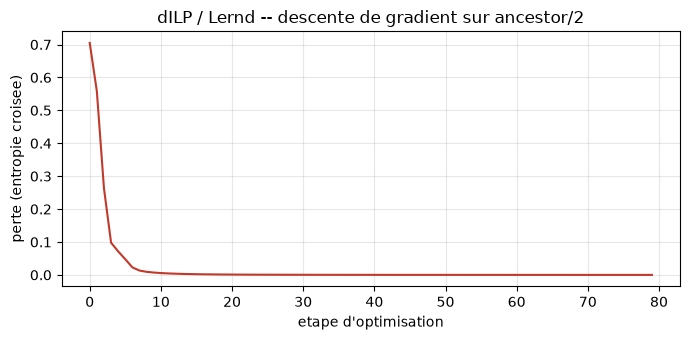

In [10]:
# Courbe de perte : la signature d'un apprentissage par gradient (vs recherche discrete).
import matplotlib.pyplot as plt

if HAS_LERND and lernd_res:
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.plot(lernd_res["losses"], color="#c0392b")
    ax.set_xlabel("etape d'optimisation")
    ax.set_ylabel("perte (entropie croisee)")
    ax.set_title("dILP / Lernd -- descente de gradient sur ancestor/2")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Pas de courbe : Lernd indisponible.")

dILP converge (la perte chute vers ~0) et apprend, avec une **confiance** elevee,
le meme squelette recursif que Popper et Aleph. Les clauses extraites de la sortie
ci-dessus :

```text
ancestor(A,B) <- parent(A,B), parent(A,B).     % cas de base
ancestor(A,B) <- ancestor(C,B), parent(A,C).   % pas recursif
```

> **Detail honnete -- le litteral duplique.** Le gabarit du cas de base impose
> *deux* atomes de corps (`RuleTemplate(0, False)`), donc dILP remplit la seconde
> position avec une copie de `parent(A,B)` : logiquement equivalent a
> `ancestor(A,B) <- parent(A,B)`. C'est une trace du biais par **templates** : la
> ou Popper minimise la *taille* du programme, dILP cherche dans un gabarit de
> taille fixe et n'a aucune incitation a eliminer un litteral redondant.

La difference de nature : ici la solution est le **maximum d'une fonction continue**,
pas le resultat d'une recherche symbolique. C'est ce qui permet a dILP de tolerer des
etiquettes bruitees (un exemple mal classe degrade un gradient, il ne casse pas une
preuve) -- et c'est exactement la propriete qui ouvre la voie au **neuro-symbolique**
(SL-7), ou des reseaux de neurones fournissent les predicats de base.

## Synthese -- quatre machineries, un meme concept

Les quatre moteurs ont appris la **meme relation recursive** `ancestor/2`, chacun par
un mecanisme different. Le tableau ci-dessous resume ce que chaque execution a produit.

In [11]:
# Recapitulatif programmatique : on lit les resultats reels obtenus ci-dessus.
rows = [
    ("Aleph",   "entailment inverse",   "modes +/- + determination", "non",  aleph_prog is not None),
    ("Metagol", "meta-interpretation",  "metaregles base + chain",   "OUI (ancestor_1)",
     metagol_prog is not None),
    ("Popper",  "learning from failures", "enable_recursion",        "via biais",
     popper_prog is not None),
    ("dILP",    "descente de gradient", "templates de regles",       "non",  bool(lernd_res)),
]
w = (9, 22, 26, 18, 8)
hdr = ("Moteur", "Paradigme", "Biais declare", "Invention pred.", "Execute")
print("  ".join(h.ljust(width) for h, width in zip(hdr, w)))
print("  ".join("-" * width for width in w))
for name, para, bias, inv, ok in rows:
    print("  ".join(str(c).ljust(width)
                    for c, width in zip((name, para, bias, inv, "oui" if ok else "non"), w)))

print("\nTous apprennent : ancestor(A,B):-parent(A,B). ancestor(A,B):-parent(A,C),ancestor(C,B).")
print("Seul Metagol introduit un predicat auxiliaire (ancestor_1 = grandparent).")

Moteur     Paradigme               Biais declare               Invention pred.     Execute 
---------  ----------------------  --------------------------  ------------------  --------
Aleph      entailment inverse      modes +/- + determination   non                 oui     
Metagol    meta-interpretation     metaregles base + chain     OUI (ancestor_1)    oui     
Popper     learning from failures  enable_recursion            via biais           oui     
dILP       descente de gradient    templates de regles         non                 oui     

Tous apprennent : ancestor(A,B):-parent(A,B). ancestor(A,B):-parent(A,C),ancestor(C,B).
Seul Metagol introduit un predicat auxiliaire (ancestor_1 = grandparent).


## Exercices

Trois exercices pour manipuler les moteurs reels. Completez les `# TODO` ; chaque
cellule s'execute telle quelle (elle affiche un rappel tant qu'elle n'est pas completee).

In [12]:
# Exercice 1 -- Le piege de la direction de mode (Aleph)
# -----------------------------------------------------
# Dans la section Aleph, le succes dependait de modeh(ancestor(+person, -person)).
# Objectif : reproduire l'ECHEC avec deux entrees (+person, +person), puis le SUCCES
# avec une sortie (+person, -person), et expliquer la difference.
#
# Indice : reutilisez run_aleph(POS, NEG) mais en surchargeant la ligne modeh. Le plus
# simple est de copier le corps de run_aleph et de remplacer UNE ligne de modes.
#
# A completer : choisissez la direction a tester puis lancez l'apprentissage.

MODE_DIRECTION = None  # TODO : mettre "+person, +person" (echec) puis "+person, -person" (succes)

if MODE_DIRECTION is None:
    print("Exercice a completer : definir MODE_DIRECTION puis lancer Aleph avec ce modeh.")
else:
    # TODO etudiant : construire la tache Aleph avec modeh(ancestor(MODE_DIRECTION))
    #                 et observer induce (echec vs theorie apprise).
    print(f"A tester : modeh(*, ancestor({MODE_DIRECTION}))")

Exercice a completer : definir MODE_DIRECTION puis lancer Aleph avec ce modeh.


In [13]:
# Exercice 2 -- grandparent : une relation NON recursive
# ------------------------------------------------------
# ancestor est recursive ; grandparent ne l'est pas (exactement 2 sauts de parent).
# Objectif : construire les positifs grandparent par composition de PARENT (sans cloture
# transitive complete), puis lancer UN moteur de votre choix (Popper recommande, biais
# non recursif : max_clauses(1), pas de enable_recursion).
#
# Indice : grandparent(X, Z) ssi il existe Y tel que parent(X, Y) et parent(Y, Z).

def grandparents(parent_edges):
    """Retourne l'ensemble des couples (X, Z) grand-parent -> petit-enfant."""
    result = set()
    # TODO etudiant : remplir result a partir de parent_edges (2 sauts).
    return result


GP_POS = sorted(grandparents(PARENT))
if not GP_POS:
    print("Exercice a completer : implementer grandparents() puis lancer un moteur ILP.")
else:
    print(f"grandparent positifs : {GP_POS}")
    # TODO etudiant : derouler run_popper avec un biais NON recursif sur grandparent.

Exercice a completer : implementer grandparents() puis lancer un moteur ILP.


In [14]:
# Exercice 3 -- Robustesse au bruit (dILP vs symbolique)
# ------------------------------------------------------
# Atout annonce de dILP : tolerer des etiquettes bruitees la ou un moteur symbolique
# exact echoue ou sur-ajuste. Objectif : injecter UN faux positif (un couple non-ancetre
# etiquete positif), relancer dILP, et comparer la confiance des clauses a la version
# propre. Puis tenter le meme bruit avec Popper et observer la difference.
#
# Indice : POS_BRUITE = POS + [un couple pris dans NEG]. dILP devrait rester proche de
# la bonne theorie (confiance un peu degradee) ; Popper exact n'a pas de notion de bruit.

NOISE_PAIR = None  # TODO : choisir un couple de NEG a injecter comme faux positif

if NOISE_PAIR is None:
    print("Exercice a completer : choisir NOISE_PAIR puis comparer dILP propre vs bruite.")
else:
    POS_BRUITE = sorted(set(POS) | {NOISE_PAIR})
    print(f"positifs bruites : {len(POS_BRUITE)} (dont le faux positif {NOISE_PAIR})")
    # TODO etudiant : relancer dILP/Popper sur POS_BRUITE et comparer aux resultats propres.

Exercice a completer : choisir NOISE_PAIR puis comparer dILP propre vs bruite.


## Conclusion

Quatre moteurs ILP **reels**, une seule tache, quatre machineries :

- **Aleph** -- l'entailment inverse de Progol, pilote par des modes declares (et sensible
  a leur direction) ;
- **Metagol** -- la meta-interpretation, seule a **inventer un predicat** auxiliaire ;
- **Popper** -- l'apprentissage par l'echec, le moteur symbolique general de reference ;
- **dILP** -- l'ILP differentiable, qui apprend par gradient et **fait le pont vers le
  neuro-symbolique** (SL-7).

Le choix d'un moteur depend de la tache : exactitude et lisibilite symboliques (Aleph,
Metagol, Popper) versus robustesse au bruit et integration neuronale (dILP).

## Ressources

- Srinivasan, A. (2001), *The Aleph Manual*
- Muggleton, S., Lin, D., Tamaddoni-Nezhad, A. (2015), *Meta-interpretive learning of higher-order dyadic datalog*, Machine Learning 100
- Cropper, A., Morel, R. (2021), *Learning programs by learning from failures*, Machine Learning 110
- Evans, R., Grefenstette, E. (2018), *Learning Explanatory Rules from Noisy Data*, JAIR 61 (arXiv:1711.04574)
- Lernd (implementation dILP) : https://github.com/crunchiness/lernd (GPL-3.0)
- Metagol (vendore, BSD-3) : `vendor/metagol/` -- voir l'attribution et la licence

---

**Retour** : [Index SymbolicLearning](./README.md) | [<< SL-5 Resolution inverse](SL-5-InverseResolution.ipynb) | [SL-7 Neuro-symbolique >>](SL-7-NeuroSymbolic.ipynb)